In [ ]:
!pip install tensorflow pandas numpy scikit-learn matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv("sentiment_large.csv") #columns: text, sentiment
df.head()

,text,sentiment
0,Exceeded my expectations!,positive
1,I regret buying this.,negative
2,Exceeded my expectations!,positive
3,I love this product!,positive
4,Really happy with the purchase.,positive


In [3]:
df['sentiment'].value_counts()
texts = df["text"].astype(str).values
labels = df["sentiment"].values

In [4]:
le = LabelEncoder()
labels = le.fit_transform(labels) # positive=1, negative=0

In [5]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

In [6]:
sequences = tokenizer.texts_to_sequences(texts)
max_len = 20

In [7]:
X = pad_sequences(sequences, maxlen=max_len)
y = labels

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [9]:
model = Sequential([
Embedding(10000, 128), # removed input_length
LSTM(128, return_sequences=False),
Dropout(0.3),
Dense(64, activation='relu'),
Dense(1, activation='sigmoid')
])

In [10]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [11]:
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 128)             │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,419,905 (5.42 MB)

 Trainable params: 1,419,905 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
X_train, y_train,
validation_data=(X_test, y_test),
epochs=15,
batch_size=64
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8167 - loss: 0.6492 - val_accuracy: 1.0000 - val_loss: 0.5195
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9552 - loss: 0.2770 - val_accuracy: 0.9333 - val_loss: 0.1583
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9917 - loss: 0.0485 - val_accuracy: 1.0000 - val_loss: 0.0118
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 8.0604e-04
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 2.6966e-04
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 1.0000 - loss: 3.7397e-04 - val_accuracy: 1.0000 - val_loss: 1.5765e-04
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 1.0000 - loss: 2.1904e-04 - val_accuracy: 1.0000 - val_loss: 1.1360e-04
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 1.0000 - loss: 1.7902e-

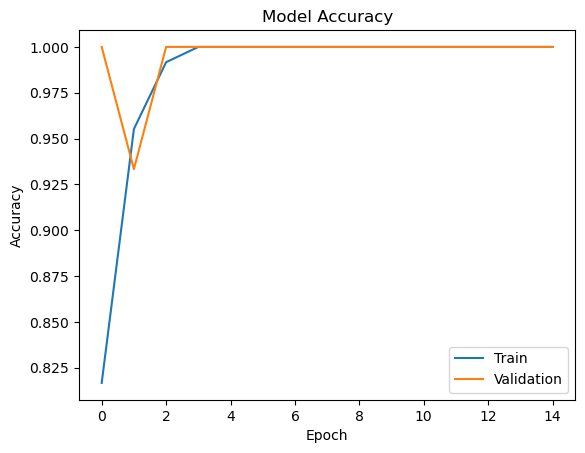

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

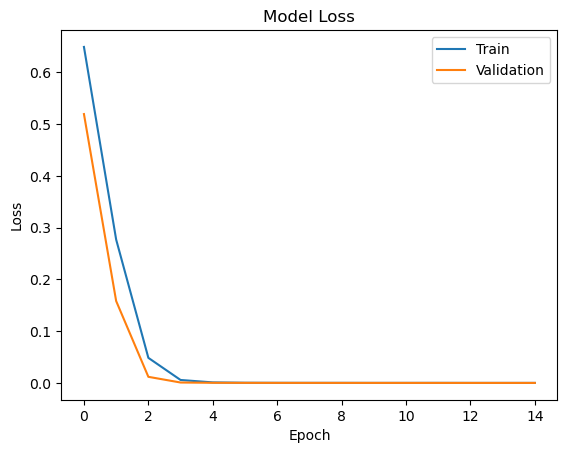

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [15]:
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model.predict(padded)[0][0]
    return "Positive" if pred > 0.4 else "Negative"